# Model 2 — GloVe 300d + Bi-LSTM Siamese Network

**Goal:** Beat TF-IDF by capturing word order and local context using a Siamese Bi-LSTM.

### Architecture
- GloVe 6B 300d pre-trained embeddings (frozen)
- Two **shared-weight** Bi-LSTM encoders (one per input passage)
- Mean pooling over Bi-LSTM hidden states → fixed-size sentence vector
- Feature vector = [u, v, |u−v|, u*v] → Dense classifier
- Binary cross-entropy loss with class weights to handle 4:1 imbalance

### Why Siamese?
Both inputs pass through the **same** LSTM (shared weights). This forces the network to learn a universal sentence representation rather than overfitting to input order.

## 1. Setup

In [1]:
import os, sys, json, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, roc_auc_score,
                              roc_curve, classification_report)

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

PROCESSED_DIR = Path('/content/drive/MyDrive/pan-processed')
RESULTS_DIR   = Path('results');        RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR    = Path('trained_models'); MODELS_DIR.mkdir(exist_ok=True)

DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 85.1 GB


## 2. Inline data loader

In [2]:
def load_pan():
    train = pd.read_csv(PROCESSED_DIR / 'pan_train.csv')
    val   = pd.read_csv(PROCESSED_DIR / 'pan_val.csv')
    test  = pd.read_csv(PROCESSED_DIR / 'pan_test.csv')
    return train, val, test

def load_quora():
    train = pd.read_csv(PROCESSED_DIR / 'quora_train.csv')
    test  = pd.read_csv(PROCESSED_DIR / 'quora_test.csv')
    return train, test

def build_pan_pairs(df_pan):
    np.random.seed(RANDOM_STATE)
    pos = df_pan[
        (df_pan['is_plagiarism'] == 1) &
        (df_pan['corpus_type']  == 'external') &
        (df_pan['source_text'].notna()) &
        (df_pan['source_text']  != 'NONE')
    ].copy()
    src_pool = pos['source_text'].values
    neg = df_pan[
        (df_pan['is_plagiarism'] == 0) &
        (df_pan['corpus_type']  == 'external')
    ].copy()
    if len(neg) > 0:
        neg['source_text'] = np.random.choice(src_pool, size=len(neg))
    out = pd.concat([pos, neg], ignore_index=True)
    out = out.rename(columns={
        'suspicious_text': 'text_a',
        'source_text'    : 'text_b',
        'is_plagiarism'  : 'label',
    })
    return out[['text_a', 'text_b', 'label', 'plagiarism_type', 'obfuscation']].reset_index(drop=True)

def get_quora_pairs(df):
    return df.rename(columns={
        'q1_clean': 'text_a', 'q2_clean': 'text_b', 'is_duplicate': 'label'
    })[['text_a', 'text_b', 'label']].reset_index(drop=True)

## 3. Load and combine data

In [3]:
pan_train, pan_val, pan_test = load_pan()
pan_train_pairs = build_pan_pairs(pan_train)
pan_val_pairs   = build_pan_pairs(pan_val)
pan_test_pairs  = build_pan_pairs(pan_test)

qtrain, qtest = load_quora()
q_train_pairs = get_quora_pairs(qtrain)
q_test_pairs  = get_quora_pairs(qtest)
q_val_pairs   = q_train_pairs.sample(frac=0.10, random_state=RANDOM_STATE)
q_train_pairs = q_train_pairs.drop(q_val_pairs.index).reset_index(drop=True)
q_val_pairs   = q_val_pairs.reset_index(drop=True)

# Combined train and val
train_df = pd.concat([pan_train_pairs[['text_a','text_b','label']],
                      q_train_pairs[['text_a','text_b','label']]], ignore_index=True)
val_df   = pd.concat([pan_val_pairs[['text_a','text_b','label']],
                      q_val_pairs[['text_a','text_b','label']]], ignore_index=True)

print('Dataset sizes:')
for name, df in [('Combined train', train_df), ('Combined val', val_df),
                 ('PAN test', pan_test_pairs), ('Quora test', q_test_pairs)]:
    pos = df['label'].sum()
    print(f'  {name:18s} | {len(df):>7,d} rows | pos={pos:>6,d} ({pos/len(df):.1%})')

Dataset sizes:
  Combined train     | 333,785 rows | pos=142,688 (42.7%)
  Combined val       |  40,708 rows | pos=18,705 (45.9%)
  PAN test           |   9,276 rows | pos= 7,647 (82.4%)
  Quora test         |  80,827 rows | pos=29,855 (36.9%)


## 4. Download GloVe 6B 300d

In [4]:
GLOVE_DIR  = Path('/content/glove')
GLOVE_FILE = GLOVE_DIR / 'glove.6B.300d.txt'

if not GLOVE_FILE.exists():
    GLOVE_DIR.mkdir(exist_ok=True)
    print('Downloading GloVe 6B...')
    !wget -q --show-progress -O /content/glove/glove.6B.zip \
        http://nlp.stanford.edu/data/glove.6B.zip
    !unzip -q /content/glove/glove.6B.zip -d /content/glove/
    !rm /content/glove/glove.6B.zip
    print('Done.')
else:
    print('GloVe already downloaded.')

/content/glove/glov 100%[===================>] 822.24M  4.99MB/s    in 2m 41s  
Done.


## 5. Build vocabulary and embedding matrix

In [5]:
# ── Tokenizer ──────────────────────────────────────────────────────────
def simple_tokenize(text, max_len=128):
    """Lowercase, remove punctuation, split on whitespace, truncate."""
    if not isinstance(text, str):
        return []
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    tokens = text.split()[:max_len]
    return tokens

MAX_LEN   = 128   # max tokens per passage
MAX_VOCAB = 80_000

# Build vocab from training data
print('Building vocabulary...')
from collections import Counter
counter = Counter()
for col in ['text_a', 'text_b']:
    for text in tqdm(train_df[col].fillna(''), desc=f'Tokenizing {col}'):
        counter.update(simple_tokenize(text))

PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
vocab = [PAD_TOKEN, UNK_TOKEN] + [w for w, _ in counter.most_common(MAX_VOCAB - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}
VOCAB_SIZE = len(vocab)
print(f'Vocabulary size: {VOCAB_SIZE:,}')

Building vocabulary...


Tokenizing text_a:   0%|          | 0/333785 [00:00<?, ?it/s]

Tokenizing text_b:   0%|          | 0/333785 [00:00<?, ?it/s]

Vocabulary size: 80,000


In [6]:
# ── Load GloVe into embedding matrix ──────────────────────────────────
EMBED_DIM = 300
print('Loading GloVe vectors...')
glove = {}
with open(GLOVE_FILE, encoding='utf-8') as f:
    for line in tqdm(f, total=400_000, desc='GloVe'):
        parts = line.split()
        glove[parts[0]] = np.array(parts[1:], dtype=np.float32)

# Build embedding matrix — rows indexed by word2idx
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM), dtype=np.float32)
found, notfound  = 0, 0
for word, idx in word2idx.items():
    if word in glove:
        embedding_matrix[idx] = glove[word]
        found += 1
    else:
        embedding_matrix[idx] = np.random.normal(0, 0.1, EMBED_DIM)  # random init for OOV
        notfound += 1

print(f'GloVe coverage: {found:,} / {VOCAB_SIZE:,} words ({found/VOCAB_SIZE:.1%})')
del glove  # free RAM

Loading GloVe vectors...


GloVe:   0%|          | 0/400000 [00:00<?, ?it/s]

GloVe coverage: 63,781 / 80,000 words (79.7%)


## 6. PyTorch Dataset and DataLoader

In [7]:
def encode(text, word2idx, max_len=MAX_LEN):
    tokens  = simple_tokenize(text, max_len)
    ids     = [word2idx.get(t, 1) for t in tokens]  # 1 = UNK
    # Pad to max_len
    ids     = ids[:max_len] + [0] * max(0, max_len - len(ids))
    return ids


class PairDataset(Dataset):
    def __init__(self, df, word2idx, max_len=MAX_LEN):
        self.a      = df['text_a'].fillna('').tolist()
        self.b      = df['text_b'].fillna('').tolist()
        self.labels = df['label'].astype(int).tolist()
        self.word2idx = word2idx
        self.max_len  = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        a = torch.tensor(encode(self.a[idx], self.word2idx, self.max_len), dtype=torch.long)
        b = torch.tensor(encode(self.b[idx], self.word2idx, self.max_len), dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.float)
        return a, b, y


BATCH_SIZE = 256  # A100 can handle this easily

train_dataset = PairDataset(train_df, word2idx)
val_dataset   = PairDataset(val_df,   word2idx)
pan_dataset   = PairDataset(pan_test_pairs, word2idx)
q_dataset     = PairDataset(q_test_pairs,   word2idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
pan_loader   = DataLoader(pan_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
q_loader     = DataLoader(q_dataset,     batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader):,}')
print(f'Val batches   : {len(val_loader):,}')

Train batches : 1,304
Val batches   : 160


## 7. Siamese Bi-LSTM Model

In [8]:
class SiameseBiLSTM(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape

        # Embedding layer — initialized with GloVe, frozen
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embedding_matrix), requires_grad=False
        )

        # Shared Bi-LSTM encoder
        self.lstm = nn.LSTM(
            input_size   = embed_dim,
            hidden_size  = hidden_dim,
            num_layers   = num_layers,
            batch_first  = True,
            bidirectional= True,
            dropout      = dropout if num_layers > 1 else 0,
        )

        # After Bi-LSTM: hidden_dim * 2 per direction
        lstm_out_dim = hidden_dim * 2

        # Classifier: [u, v, |u-v|, u*v]
        self.classifier = nn.Sequential(
            nn.Linear(lstm_out_dim * 4, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def encode(self, x):
        """Encode a batch of token sequences → mean-pooled Bi-LSTM output."""
        mask  = (x != 0).float()                      # (B, L)
        emb   = self.embedding(x)                      # (B, L, E)
        out, _ = self.lstm(emb)                        # (B, L, 2H)
        # Mean pooling over non-padding positions
        lengths = mask.sum(dim=1, keepdim=True).clamp(min=1)  # (B, 1)
        pooled  = (out * mask.unsqueeze(-1)).sum(dim=1) / lengths  # (B, 2H)
        return pooled

    def forward(self, a, b):
        u = self.encode(a)                             # (B, 2H)
        v = self.encode(b)                             # (B, 2H)
        # Feature vector: concatenate u, v, |u-v|, u*v
        feat  = torch.cat([u, v, torch.abs(u - v), u * v], dim=1)  # (B, 8H)
        logit = self.classifier(feat).squeeze(1)       # (B,)
        return logit


model = SiameseBiLSTM(
    embedding_matrix = embedding_matrix,
    hidden_dim       = 256,
    num_layers       = 2,
    dropout          = 0.3,
).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total_params:,}')
print(f'Trainable params: {trainable_params:,}  (GloVe embeddings frozen)')

Total params    : 27,834,625
Trainable params: 3,834,625  (GloVe embeddings frozen)


## 8. Training loop

In [10]:
# Class weight to handle 4:1 positive imbalance
pos_weight = torch.tensor(
    [(train_df['label'] == 0).sum() / (train_df['label'] == 1).sum()],
    dtype=torch.float
).to(DEVICE)

criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer  = Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler  = ReduceLROnPlateau(optimizer, mode='max', patience=2, factor=0.5)

EPOCHS     = 10
best_val_f1 = 0
history     = []

for epoch in range(1, EPOCHS + 1):
    # ── Train ────────────────────────────────────────────────────────
    model.train()
    train_loss = 0
    for a, b, y in tqdm(train_loader, desc=f'Epoch {epoch}/{EPOCHS} train', leave=False):
        a, b, y = a.to(DEVICE), b.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        logits = model(a, b)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    # ── Validate ─────────────────────────────────────────────────────
    model.eval()
    val_loss  = 0
    val_preds, val_labels, val_probs = [], [], []
    with torch.no_grad():
        for a, b, y in val_loader:
            a, b, y = a.to(DEVICE), b.to(DEVICE), y.to(DEVICE)
            logits  = model(a, b)
            loss    = criterion(logits, y)
            val_loss += loss.item()
            probs   = torch.sigmoid(logits).cpu().numpy()
            preds   = (probs >= 0.5).astype(int)
            val_probs.extend(probs)
            val_preds.extend(preds)
            val_labels.extend(y.cpu().numpy().astype(int))

    val_f1  = f1_score(val_labels, val_preds, zero_division=0)
    val_acc = accuracy_score(val_labels, val_preds)
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss   / len(val_loader)

    history.append({'epoch': epoch, 'train_loss': avg_train_loss,
                    'val_loss': avg_val_loss, 'val_f1': val_f1, 'val_acc': val_acc})

    print(f'Epoch {epoch:02d} | train_loss={avg_train_loss:.4f} | '
          f'val_loss={avg_val_loss:.4f} | val_f1={val_f1:.4f} | val_acc={val_acc:.4f}')

    scheduler.step(val_f1)

    # Save best model
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), MODELS_DIR / 'model2_bilstm_best.pt')
        print(f'  → Best model saved (val F1={val_f1:.4f})')

print(f'\nTraining complete. Best val F1: {best_val_f1:.4f}')

Epoch 1/10 train:   0%|          | 0/1304 [00:00<?, ?it/s]

Epoch 01 | train_loss=0.4996 | val_loss=0.3848 | val_f1=0.8293 | val_acc=0.8340
  → Best model saved (val F1=0.8293)


Epoch 2/10 train:   0%|          | 0/1304 [00:00<?, ?it/s]

Epoch 02 | train_loss=0.3899 | val_loss=0.3529 | val_f1=0.8487 | val_acc=0.8505
  → Best model saved (val F1=0.8487)


Epoch 3/10 train:   0%|          | 0/1304 [00:00<?, ?it/s]

...

Epoch 08 | train_loss=0.1424 | val_loss=0.4664 | val_f1=0.8759 | val_acc=0.8822
  → Best model saved (val F1=0.8759)


Epoch 9/10 train:   0%|          | 0/1304 [00:00<?, ?it/s]

Epoch 09 | train_loss=0.1217 | val_loss=0.4657 | val_f1=0.8749 | val_acc=0.8817


Epoch 10/10 train:   0%|          | 0/1304 [00:00<?, ?it/s]

Epoch 10 | train_loss=0.1045 | val_loss=0.5422 | val_f1=0.8758 | val_acc=0.8841

Training complete. Best val F1: 0.8759


## 9. Training curves

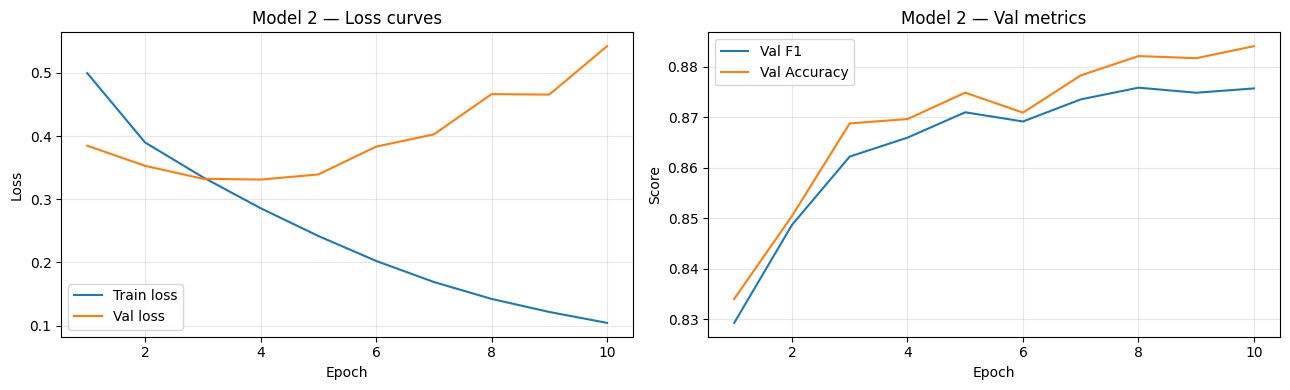

In [12]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(hist_df['epoch'], hist_df['train_loss'], label='Train loss')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'],   label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Model 2 — Loss curves'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_df['epoch'], hist_df['val_f1'],  label='Val F1')
axes[1].plot(hist_df['epoch'], hist_df['val_acc'], label='Val Accuracy')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
axes[1].set_title('Model 2 — Val metrics'); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model2_training_curves.png', dpi=120)
plt.show()

## 10. Load best model and evaluate

In [13]:
def predict(loader, model, device, threshold=0.5):
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for a, b, y in tqdm(loader, desc='Predicting'):
            a, b = a.to(device), b.to(device)
            probs = torch.sigmoid(model(a, b)).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(y.numpy().astype(int))
    probs  = np.array(all_probs)
    labels = np.array(all_labels)
    preds  = (probs >= threshold).astype(int)
    return probs, preds, labels


def evaluate(probs, preds, labels, name):
    metrics = {
        'dataset'  : name,
        'n'        : len(labels),
        'accuracy' : accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, zero_division=0),
        'recall'   : recall_score(labels, preds, zero_division=0),
        'f1'       : f1_score(labels, preds, zero_division=0),
        'roc_auc'  : roc_auc_score(labels, probs) if len(np.unique(labels)) > 1 else float('nan'),
    }
    print(f'\n── {name} ─────────────────────────────────')
    for k, v in metrics.items():
        print(f'  {k:9s}: {v:.4f}' if isinstance(v, float) else f'  {k:9s}: {v}')
    print(f'\n{classification_report(labels, preds, target_names=["non-plag","plagiarism"], zero_division=0)}')
    return metrics


# Load best checkpoint
model.load_state_dict(torch.load(MODELS_DIR / 'model2_bilstm_best.pt', map_location=DEVICE))

pan_probs, pan_preds, pan_labels = predict(pan_loader, model, DEVICE)
q_probs,   q_preds,   q_labels   = predict(q_loader,   model, DEVICE)

pan_metrics = evaluate(pan_probs, pan_preds, pan_labels, 'PAN test')
q_metrics   = evaluate(q_probs,   q_preds,   q_labels,   'Quora test')

results_df = pd.DataFrame([pan_metrics, q_metrics])
results_df.to_csv(RESULTS_DIR / 'model2_metrics.csv', index=False)
print('\n── Final Results ──')
print(results_df.to_string(index=False))

Predicting:   0%|          | 0/37 [00:00<?, ?it/s]

Predicting:   0%|          | 0/316 [00:00<?, ?it/s]


── PAN test ─────────────────────────────────
  dataset  : PAN test
  n        : 9276
  accuracy : 0.9928
  precision: 0.9978
  recall   : 0.9935
  f1       : 0.9956
  roc_auc  : 0.9995

              precision    recall  f1-score   support

    non-plag       0.97      0.99      0.98      1629
  plagiarism       1.00      0.99      1.00      7647

    accuracy                           0.99      9276
   macro avg       0.98      0.99      0.99      9276
weighted avg       0.99      0.99      0.99      9276


── Quora test ─────────────────────────────────
  dataset  : Quora test
  n        : 80827
  accuracy : 0.8546
  precision: 0.7760
  recall   : 0.8523
  f1       : 0.8124
  roc_auc  : 0.9289

              precision    recall  f1-score   support

    non-plag       0.91      0.86      0.88     50972
  plagiarism       0.78      0.85      0.81     29855

    accuracy                           0.85     80827
   macro avg       0.84      0.85      0.85     80827
weighted avg       0

## 11. Confusion matrices + ROC

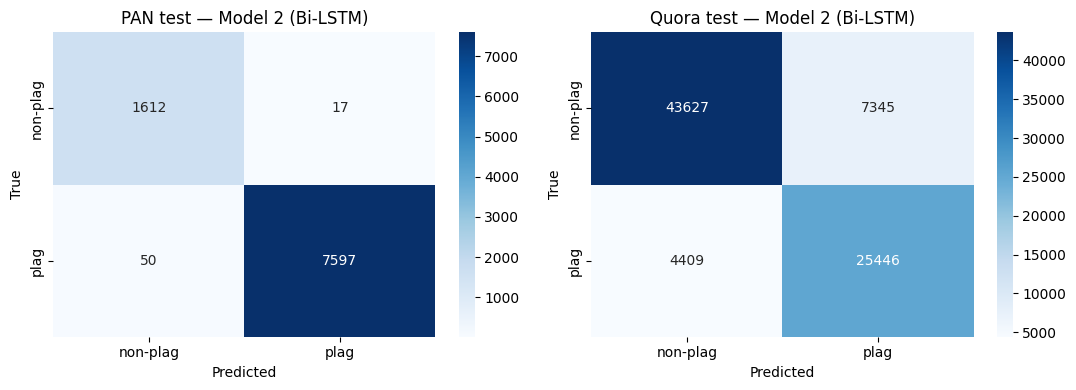

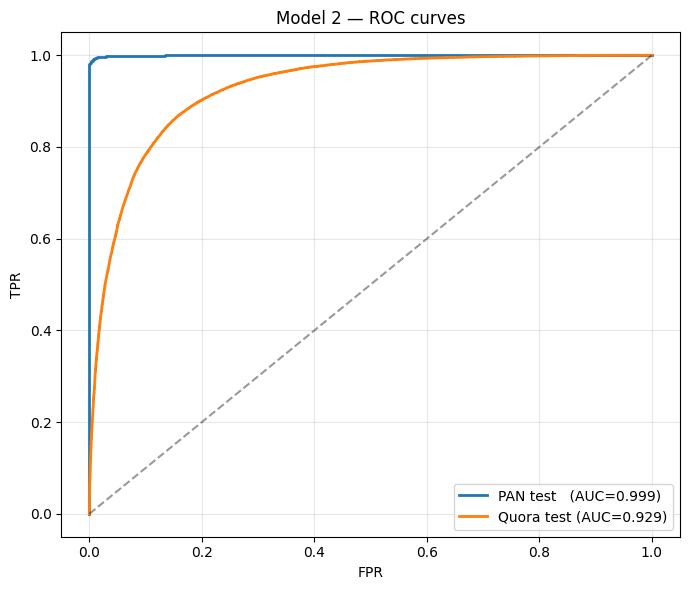

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (name, labels, preds) in zip(axes, [
    ('PAN test',   pan_labels, pan_preds),
    ('Quora test', q_labels,   q_preds),
]):
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['non-plag','plag'],
                yticklabels=['non-plag','plag'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{name} — Model 2 (Bi-LSTM)')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model2_confusion_matrices.png', dpi=120)
plt.show()

# ROC
fig, ax = plt.subplots(figsize=(7, 6))
for name, probs, labels in [
    (f'PAN test   (AUC={pan_metrics["roc_auc"]:.3f})', pan_probs, pan_labels),
    (f'Quora test (AUC={q_metrics["roc_auc"]:.3f})',   q_probs,   q_labels),
]:
    fpr, tpr, _ = roc_curve(labels, probs)
    ax.plot(fpr, tpr, label=name, linewidth=2)
ax.plot([0,1],[0,1],'k--',alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Model 2 — ROC curves')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'model2_roc.png', dpi=120)
plt.show()

## 12. Per-obfuscation breakdown (PAN)

In [15]:
pan_aug = pan_test_pairs.copy()
pan_aug['prob']       = pan_probs
pan_aug['prediction'] = pan_preds
pan_aug['correct']    = (pan_aug['prediction'] == pan_aug['label']).astype(int)

print('── By plagiarism_type ──')
print(pan_aug.groupby('plagiarism_type').apply(lambda g: pd.Series({
    'total'   : len(g),
    'pos'     : int(g['label'].sum()),
    'accuracy': round(g['correct'].mean(), 3),
    'avg_prob': round(g['prob'].mean(), 3),
})).to_string())

print('\n── By obfuscation level (positive cases only) ──')
pos_only = pan_aug[pan_aug['label'] == 1]
print(pos_only.groupby('obfuscation').apply(lambda g: pd.Series({
    'total'   : len(g),
    'detected': int(g['prediction'].sum()),
    'recall'  : round(g['prediction'].mean(), 3),
    'avg_prob': round(g['prob'].mean(), 3),
})).to_string())

── By plagiarism_type ──
                  total     pos  accuracy  avg_prob
plagiarism_type                                    
artificial       5722.0  5722.0     0.996     0.996
none             1629.0     0.0     0.990     0.012
simulated        1066.0  1066.0     0.982     0.981
translation       859.0   859.0     0.990     0.988

── By obfuscation level (positive cases only) ──
              total  detected  recall  avg_prob
obfuscation                                    
NONE         1925.0    1897.0   0.985     0.984
high         2765.0    2743.0   0.992     0.992
low          2865.0    2865.0   1.000     1.000
none           92.0      92.0   1.000     1.000


/tmp/ipykernel_24576/3605100947.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(pan_aug.groupby('plagiarism_type').apply(lambda g: pd.Series({
/tmp/ipykernel_24576/3605100947.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(pos_only.groupby('obfuscation').apply(lambda g: pd.Series({


## 13. Save everything

In [16]:
# Save vocab for inference
import pickle
with open(MODELS_DIR / 'model2_word2idx.pkl', 'wb') as f:
    pickle.dump(word2idx, f)

# Save results JSON
with open(RESULTS_DIR / 'model2_results.json', 'w') as f:
    json.dump({'pan': pan_metrics, 'quora': q_metrics}, f, indent=4)

print('Saved:')
print(f'  {MODELS_DIR}/model2_bilstm_best.pt')
print(f'  {MODELS_DIR}/model2_word2idx.pkl')
print(f'  {RESULTS_DIR}/model2_metrics.csv')
print(f'  {RESULTS_DIR}/model2_results.json')
print(f'\nModel 2 complete. Best val F1: {best_val_f1:.4f}')

Saved:
  trained_models/model2_bilstm_best.pt
  trained_models/model2_word2idx.pkl
  results/model2_metrics.csv
  results/model2_results.json

Model 2 complete. Best val F1: 0.8759
